# 1.Instagram GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [62]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD FACEBOOK GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/instagram_graph.csv"
)

print("=" * 60)
print("INSTAGRAM GRAPH DATA")
print("=" * 60)

print(df.shape)

INSTAGRAM GRAPH DATA
(30195, 32)


In [63]:
import pandas as pd
import numpy as np
from itertools import combinations
import csv
import time
from collections import defaultdict

start_time = time.time()

# =====================================================
# CREATE INSTAGRAM NODE FILE
# =====================================================

print("Creating Instagram Nodes...")

nodes_df = df.copy()

nodes_df = nodes_df.rename(
    columns={"post_id": "Id"}
)

nodes_df["Label"] = nodes_df["Id"].astype(str)

node_cols = [

    "Id",
    "Label",

    "topic",

    "verified",

    "followers",

    "sentiment_positive",

    "popularity"
]

nodes_export = nodes_df[node_cols]

nodes_export.to_csv(

    "instagram_node.csv",

    index=False,

    encoding="utf-8"
)

print(
    f"✅ Saved instagram_node.csv with {len(nodes_export)} nodes."
)

# =====================================================
# PREPARE RECORDS
# =====================================================

columns_needed = [

    "post_id",

    "topic",

    "verified",

    "followers",

    "sentiment_positive"
]

records = df[
    columns_needed
].values.tolist()

# =====================================================
# STORE TOP-K NEIGHBORS
# =====================================================

TOP_K = 5

neighbors_dict = defaultdict(list)

print("\nBuilding KNN-style Instagram Graph...")

# =====================================================
# COMPARE ALL PAIRS
# =====================================================

for idx, (row_i, row_j) in enumerate(
    combinations(records, 2)
):

    # =================================================
    # MUST SHARE TOPIC
    # =================================================

    if row_i[1] != row_j[1]:
        continue

    # =================================================
    # SCORE
    # =================================================

    score = 2
    # same topic guaranteed

    # -------------------------------------------------
    # VERIFIED
    # -------------------------------------------------

    if row_i[2] == 1 and row_j[2] == 1:

        score += 1

    # -------------------------------------------------
    # FOLLOWER SIMILARITY
    # -------------------------------------------------

    f_i, f_j = row_i[3], row_j[3]

    if f_i > 0 and f_j > 0:

        ratio = (
            f_i / f_j
            if f_i < f_j
            else f_j / f_i
        )

        if ratio >= 0.8:

            score += 1

    # -------------------------------------------------
    # SENTIMENT SIMILARITY
    # -------------------------------------------------

    sentiment_diff = abs(
        row_i[4] - row_j[4]
    )

    if sentiment_diff <= 0.15:

        score += 1

    # =================================================
    # KEEP ONLY STRONG RELATIONS
    # =================================================

    if score >= 3:

        # store for node i
        neighbors_dict[row_i[0]].append(
            (row_j[0], score)
        )

        # store for node j
        neighbors_dict[row_j[0]].append(
            (row_i[0], score)
        )

    # =================================================
    # PROGRESS
    # =================================================

    if idx % 1000000 == 0 and idx > 0:

        print(
            f"Processed {idx:,} pairs..."
        )

# =====================================================
# CREATE EDGE FILE
# =====================================================

print("\nSaving Top-K Edges...")

edge_file = open(

    "instagram_edge.csv",

    mode="w",

    newline="",

    encoding="utf-8"
)

writer = csv.writer(edge_file)

writer.writerow([
    "Source",
    "Target",
    "Weight",
    "Type"
])

# =====================================================
# REMOVE DUPLICATES
# =====================================================

edge_set = set()

edge_count = 0

for source_node, neighbor_list in neighbors_dict.items():

    # =================================================
    # SORT BY SCORE DESC
    # =================================================

    neighbor_list = sorted(

        neighbor_list,

        key=lambda x: x[1],

        reverse=True
    )

    # =================================================
    # KEEP TOP-K ONLY
    # =================================================

    top_neighbors = neighbor_list[:TOP_K]

    for target_node, score in top_neighbors:

        edge_key = tuple(
            sorted([source_node, target_node])
        )

        if edge_key not in edge_set:

            edge_set.add(edge_key)

            writer.writerow([

                source_node,

                target_node,

                score,

                "Undirected"
            ])

            edge_count += 1

# =====================================================
# CLOSE FILE
# =====================================================

edge_file.close()

print("\n" + "=" * 60)
print("INSTAGRAM KNN GRAPH COMPLETED 🚀")
print("=" * 60)

print(f"TOP_K: {TOP_K}")

print(f"Final Edges: {edge_count:,}")

print(
    f"⏱️ Runtime: {round(time.time() - start_time, 2)} sec"
)

Creating Instagram Nodes...
✅ Saved instagram_node.csv with 30195 nodes.

Building KNN-style Instagram Graph...
Processed 11,000,000 pairs...
Processed 19,000,000 pairs...
Processed 43,000,000 pairs...
Processed 57,000,000 pairs...
Processed 67,000,000 pairs...
Processed 70,000,000 pairs...
Processed 103,000,000 pairs...
Processed 110,000,000 pairs...
Processed 131,000,000 pairs...
Processed 146,000,000 pairs...
Processed 169,000,000 pairs...
Processed 175,000,000 pairs...
Processed 178,000,000 pairs...
Processed 193,000,000 pairs...
Processed 196,000,000 pairs...
Processed 211,000,000 pairs...
Processed 229,000,000 pairs...
Processed 235,000,000 pairs...
Processed 239,000,000 pairs...
Processed 251,000,000 pairs...
Processed 255,000,000 pairs...
Processed 267,000,000 pairs...
Processed 275,000,000 pairs...
Processed 289,000,000 pairs...
Processed 297,000,000 pairs...
Processed 338,000,000 pairs...
Processed 362,000,000 pairs...
Processed 367,000,000 pairs...
Processed 368,000,000 pair

In [64]:
import pandas as pd

graph_df = pd.read_csv(
    "instagram-result-1.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(30195, 18)

Columns:
['Id', 'topic', 'verified', 'followers', 'sentiment_positive', 'popularity', 'Degree', 'Weighted Degree', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'componentnumber', 'modularity_class', 'eigencentrality']


In [65]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    
    "Id",
    "pageranks",
    "Degree",
    "Authority",
    "Hub",
    "Weighted Degree",
    "modularity_class",
    "Eccentricity",
    "closnesscentrality",
    "harmonicclosnesscentrality",
    "betweenesscentrality",
    "componentnumber",
    "eigencentrality"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(30195, 13)


In [66]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [67]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [68]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [69]:
# LOAD FACEBOOK TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (24156, 58)
Test Shape : (6039, 58)


In [70]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [71]:
# CHECK MISSING GRAPH FEATURES
# =====================================================

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)

print("\nTrain Missing:")

print(
    train_hybrid[
        [
            "pageranks",
            "Degree"
        ]
    ].isnull().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        [
            "pageranks",
            "Degree"
        ]
    ].isnull().sum()
)



MISSING VALUES CHECK

Train Missing:
pageranks    0
Degree       0
dtype: int64

Test Missing:
pageranks    0
Degree       0
dtype: int64


In [72]:
# FILL MISSING VALUES
# =====================================================
# some nodes may not exist in graph export
# =====================================================

graph_cols = [
    "pageranks",
    "Degree",
    "Authority",
    "Hub",
    "Weighted Degree",
    "modularity_class",
    "Eccentricity",
    "closnesscentrality",
    "harmonicclosnesscentrality",
    "betweenesscentrality",
    "componentnumber",
    "eigencentrality"
]

train_hybrid[graph_cols] = train_hybrid[
    graph_cols
].fillna(0)

test_hybrid[graph_cols] = test_hybrid[
    graph_cols
].fillna(0)

print("\n" + "=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Hybrid:", train_hybrid.shape)
print("Test Hybrid :", test_hybrid.shape)


HYBRID DATASETS
Train Hybrid: (24156, 70)
Test Hybrid : (6039, 70)


In [73]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "instagram_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "instagram_hybrid_test.csv",
    index=False
)

In [74]:
# =====================================================
# FACEBOOK HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [75]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "instagram_hybrid_train.csv"
)

test_df = pd.read_csv(
    "instagram_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (24156, 70)
Test Shape : (6039, 70)


In [76]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [77]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (24156, 67)
X_test Shape : (6039, 67)


In [78]:
# XGBOOST MODEL
# =====================================================

model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,

    random_state=42,

    n_jobs=-1
)

In [79]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [80]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [81]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [84]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4828
           1       0.68      0.44      0.53      1211

    accuracy                           0.85      6039
   macro avg       0.78      0.69      0.72      6039
weighted avg       0.83      0.85      0.83      6039

ROC-AUC  : 0.8677


In [85]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[4585  243]
 [ 684  527]]


In [86]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                   feature  importance
3                followers    0.312441
40          language_Hindi    0.019618
33            topic_Sports    0.018893
25     topic_Entertainment    0.016456
23           topic_Climate    0.016423
32           topic_Science    0.016042
22          topic_Business    0.016026
7             num_hashtags    0.014706
43     language_Portuguese    0.014606
49           location_Asia    0.014046
45         media_type_Link    0.013678
5                 verified    0.013472
28              topic_Food    0.013470
9       sentiment_negative    0.013428
62      closnesscentrality    0.013158
53  location_South America    0.013146
39         language_German    0.013127
66         eigencentrality    0.013028
51  location_North America    0.012996
60        modularity_class    0.012935


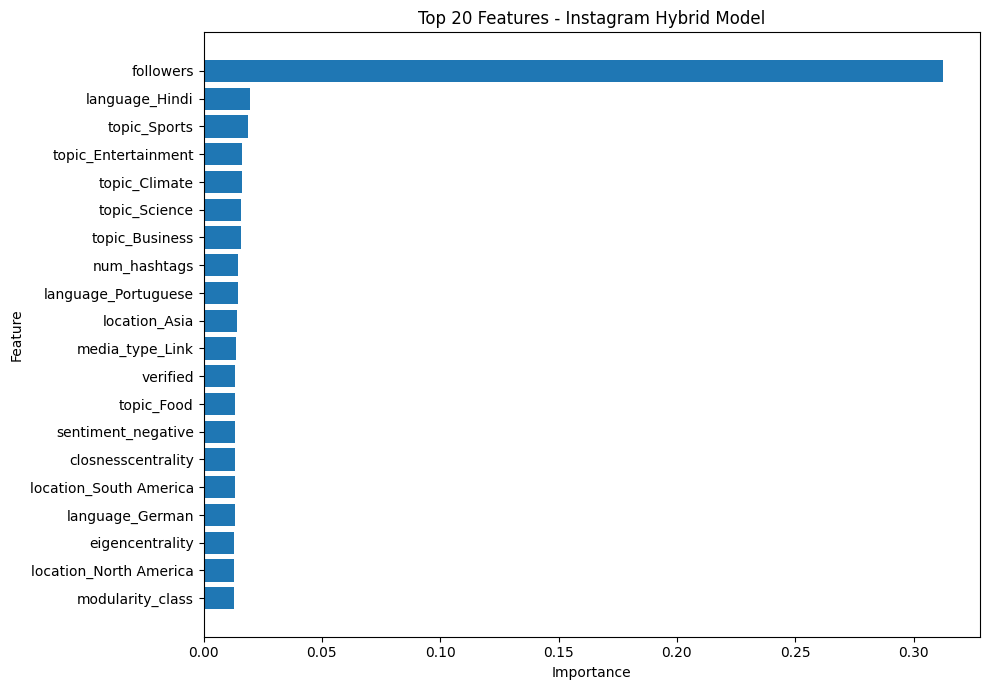

In [87]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Instagram Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. FACEBOOK NODE2VEC

 GRAPH EMBEDDING

In [99]:
# LOAD GRAPH FEATURES FILE
# =====================================================
import pandas as pd

graph_df = pd.read_csv(
    "instagram-result-1.csv"
)

print("=" * 60)
print("GRAPH DATA")
print("=" * 60)

print(graph_df.shape)


GRAPH DATA
(30195, 18)


In [89]:
# CREATE NETWORKX GRAPH
# =====================================================

G = nx.Graph()

# =====================================================
# ADD NODES
# =====================================================

for idx, row in graph_df.iterrows():

    G.add_node(
        row["Id"]
    )

# =====================================================
# CREATE EDGES
# =====================================================
# IMPORTANT:
# Need original graph edge list
# =====================================================

# If you exported edge list from Gephi:
# load it here

edges_df = pd.read_csv(
    "instagram_edge.csv"
)

print("\nEdges Shape:")
print(edges_df.shape)

# =====================================================
# ADD EDGES
# =====================================================

for idx, row in edges_df.iterrows():

    source = row["Source"]
    target = row["Target"]

    # optional weight
    if "Weight" in edges_df.columns:

        G.add_edge(
            source,
            target,
            weight=row["Weight"]
        )

    else:

        G.add_edge(
            source,
            target
        )

print("\nGraph Created 🚀")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Edges Shape:
(137809, 4)

Graph Created 🚀
Nodes: 30195
Edges: 137809


In [90]:
# NODE2VEC
# =====================================================
from node2vec import Node2Vec


print("\n" + "=" * 60)
print("TRAINING NODE2VEC...")
print("=" * 60)

node2vec = Node2Vec(

    G,

    dimensions=32,

    walk_length=10,

    num_walks=20,

    workers=4,

    weight_key="weight",

    seed=42
)

model = node2vec.fit(

    window=5,

    min_count=1,

    batch_words=64
)

print("\nNode2Vec completed 🚀")



TRAINING NODE2VEC...


Computing transition probabilities:   0%|          | 0/30195 [00:00<?, ?it/s]


Node2Vec completed 🚀


In [91]:
# CREATE EMBEDDING DATAFRAME
# =====================================================

embeddings = []

for node in G.nodes():

    vector = model.wv[str(node)]

    row_data = {

        "post_id": node
    }

    # embedding dimensions
    for i in range(len(vector)):

        row_data[f"n2v_{i}"] = vector[i]

    embeddings.append(row_data)

embedding_df = pd.DataFrame(
    embeddings
)

print("\nEmbedding Shape:")
print(embedding_df.shape)


Embedding Shape:
(30195, 33)


In [92]:
# SAVE EMBEDDINGS
# =====================================================

embedding_df.to_csv(
    "instagram_node2vec_embeddings.csv",
    index=False
)

print("\nNode2Vec embeddings saved 🚀")


Node2Vec embeddings saved 🚀


In [93]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [94]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (24156, 58)
Test Shape : (6039, 58)


In [95]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "instagram_node2vec_embeddings.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(30195, 33)

Embedding Columns:
Index(['post_id', 'n2v_0', 'n2v_1', 'n2v_2', 'n2v_3', 'n2v_4', 'n2v_5',
       'n2v_6', 'n2v_7', 'n2v_8'],
      dtype='str')


In [96]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0

Test Missing:
0


In [100]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (24156, 87)
X_test : (6039, 87)


In [101]:
# =====================================================
# XGBOOST MODEL
# =====================================================

model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 🚀


In [102]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4828
           1       0.67      0.43      0.53      1211

    accuracy                           0.84      6039
   macro avg       0.77      0.69      0.72      6039
weighted avg       0.83      0.84      0.83      6039

ROC-AUC  : 0.8614


In [103]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                   feature  importance
15           followers_log    0.247558
3                followers    0.130851
5                 verified    0.031106
33            topic_Sports    0.017513
21           large_account    0.014230
28              topic_Food    0.010833
32           topic_Science    0.009654
27           topic_Finance    0.009494
31          topic_Politics    0.008928
43     language_Portuguese    0.008883
25     topic_Entertainment    0.008632
26           topic_Fashion    0.008538
41       language_Japanese    0.008040
52        location_Oceania    0.007972
53  location_South America    0.007894
17           many_hashtags    0.007782
35            topic_Travel    0.007754
70                  n2v_15    0.007668
81                  n2v_26    0.007518
39         language_German    0.007499


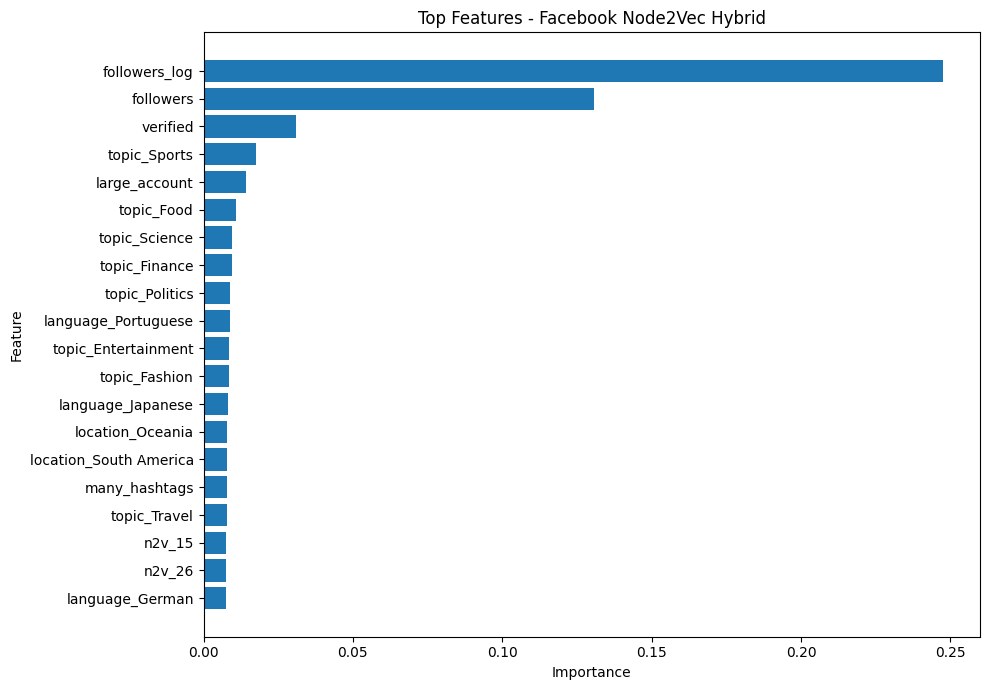

In [104]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Facebook Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Facebook graph + Node2vector

In [105]:
train_df = pd.read_csv(
    "instagram_hybrid_train.csv"
)

test_df = pd.read_csv(
    "instagram_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "instagram_node2vec_embeddings.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns[:5])


GRAPH HYBRID DATA
Train Shape: (24156, 70)
Test Shape : (6039, 70)

NODE2VEC EMBEDDINGS
(30195, 33)

Embedding Columns:
Index(['post_id', 'n2v_0', 'n2v_1', 'n2v_2', 'n2v_3'], dtype='str')


In [106]:
# MERGE NODE2VEC INTO TRAIN
# =====================================================

train_final = train_df.merge(

    embedding_df,

    on="post_id",

    how="left"
)

# =====================================================
# MERGE NODE2VEC INTO TEST
# =====================================================

test_final = test_df.merge(

    embedding_df,

    on="post_id",

    how="left"
)

print("\n" + "=" * 60)
print("AFTER MERGE")
print("=" * 60)

print("Train Shape:", train_final.shape)
print("Test Shape :", test_final.shape)



AFTER MERGE
Train Shape: (24156, 102)
Test Shape : (6039, 102)


In [107]:
# CHECK MISSING EMBEDDINGS
# =====================================================

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nMissing Train Embeddings:")

print(
    train_final[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nMissing Test Embeddings:")

print(
    test_final[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING VALUES
# =====================================================

train_final[embedding_cols] = train_final[
    embedding_cols
].fillna(0)

test_final[embedding_cols] = test_final[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_final.columns
]

train_final = train_final.drop(
    columns=existing_drop_cols
)

test_final = test_final.drop(
    columns=existing_drop_cols
)



Missing Train Embeddings:
0

Missing Test Embeddings:
0


In [108]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (24156, 99)
X_test : (6039, 99)


In [109]:
# XGBOOST MODEL
# =====================================================

model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=400,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL FACEBOOK HYBRID...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


TRAINING FINAL FACEBOOK HYBRID...

Training completed 🚀


In [110]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [111]:


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4828
           1       0.66      0.44      0.53      1211

    accuracy                           0.84      6039
   macro avg       0.76      0.69      0.72      6039
weighted avg       0.83      0.84      0.83      6039

ROC-AUC  : 0.8600


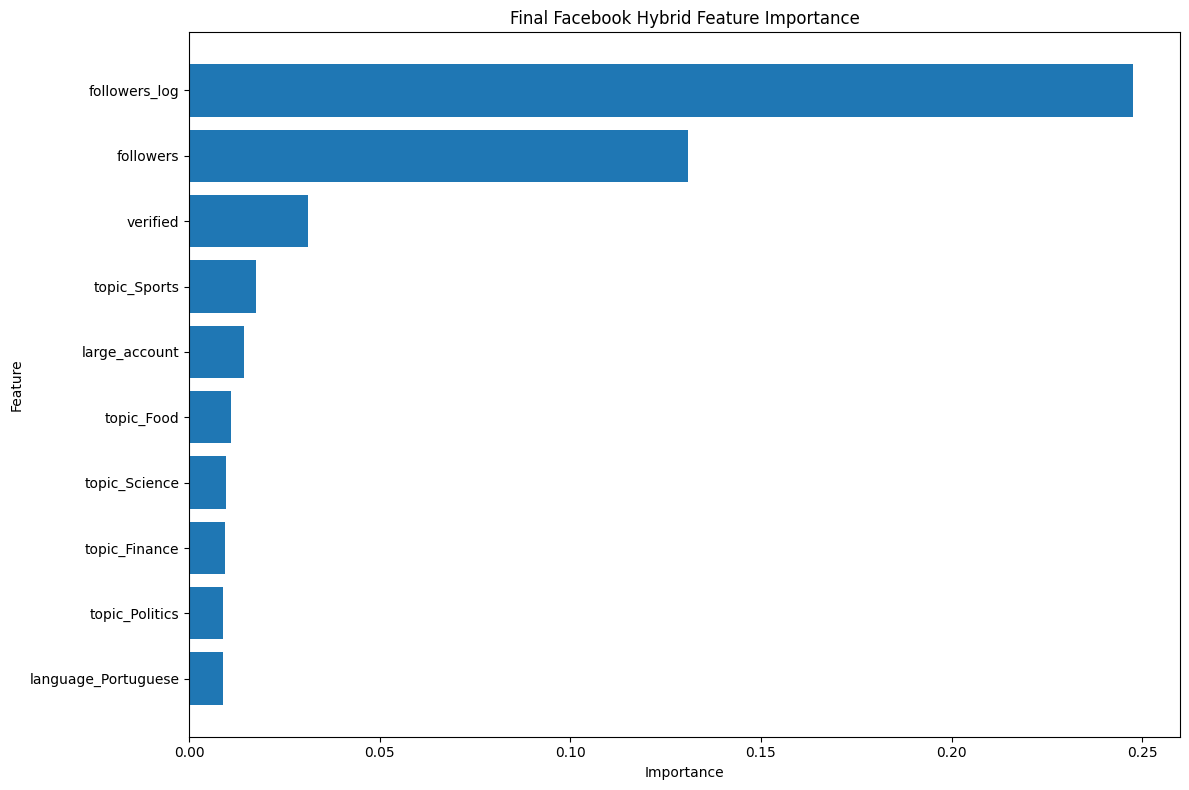

In [112]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 10

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Facebook Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()